In [2]:
import sys
import os

In [3]:
# Importeer de module
from helpers.dataframeBuilder import get_df_neigbours_answer_for_all_itemIDs


In [4]:
# from helpers.dataframeBuilder import get_df_neigbours_answer_for_all_itemIDs
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df, df_test, df_question, df_candidate = get_df_neigbours_answer_for_all_itemIDs()

In [6]:
# df_test.index = df_test.FCATestKey
# df = df.join(df_test[["FCATestKey", "VersionNumber"]], on="FCATestKey", how="left")
# df_test.reset_index(drop=True, inplace=True)
# df = pd.get_dummies(df, columns=["VersionNumber"])
# df.drop(columns="FCATestKey", inplace=True)
# df

In [7]:
X = df.select_dtypes(include=[np.number]).values

In [8]:
# Vervang NaN-waarden door de mediaan van elke kolom
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [9]:
X = X.astype(np.float64)

In [10]:
print(X.shape)

(160064, 663)


# Modellen trainen

In [11]:
# voor elke model dezelfde contamination
contamination= 0.01

In [12]:
def predict_model(model, name):
    df_answers=df

    print(f"Training {name}!")
    
    model.fit(X)
    
    df_answers['anomaly_score'] = model.decision_scores_
    df_answers['is_anomaly'] = model.predict(X)

    df_answers = df_answers.reset_index()
    df_answers = df_answers[['TestKey','anomaly_score', 'is_anomaly']]
    
    print(f"Aantal gedetecteerde anomalieën: {df_answers['is_anomaly'].sum()}")

    df_answers.set_index('TestKey', inplace=True)
    df_answers.to_csv(f"../csv/{name}.csv")
    df_answers.reset_index(inplace=True)
    
    return df_answers

## ECOD

In [13]:
from pyod.models.ecod import ECOD

# No parameters other than contamination possible, so no tuning

ecod = ECOD(contamination=contamination)

In [ ]:
df_ecod = predict_model(ecod, "ecod")

Aantal gedetecteerde anomalieën: 8004


## Isolation forest

In [25]:
from pyod.models.iforest import IForest

i_forest = IForest(contamination=contamination, n_estimators=100, max_samples='auto')
i_forest2 = IForest(contamination=contamination, n_estimators=200, max_samples='auto')
i_forest3 = IForest(contamination=contamination, n_estimators=5, max_samples='auto')
i_forest4 = IForest(contamination=contamination, n_estimators=1000, max_samples='auto')

In [26]:
df_iForest = predict_model(i_forest, 'i_forest')
df_iForest = predict_model(i_forest2, 'i_forest')
df_iForest = predict_model(i_forest3, 'i_forest')
df_iForest = predict_model(i_forest4, 'i_forest')

Training i_forest!
Aantal gedetecteerde anomalieën: 1601
Training i_forest!
Aantal gedetecteerde anomalieën: 1601
Training i_forest!
Aantal gedetecteerde anomalieën: 1592
Training i_forest!
Aantal gedetecteerde anomalieën: 1601


In [28]:
print(np.sum(i_forest.decision_scores_), np.mean(i_forest.decision_scores_), np.std(i_forest.decision_scores_))
print(np.sum(i_forest2.decision_scores_), np.mean(i_forest2.decision_scores_), np.std(i_forest2.decision_scores_))
print(np.sum(i_forest3.decision_scores_), np.mean(i_forest3.decision_scores_), np.std(i_forest3.decision_scores_))
print(np.sum(i_forest4.decision_scores_), np.mean(i_forest4.decision_scores_), np.std(i_forest4.decision_scores_))


-22260.012186180178 -0.1390694483842724 0.030865254309253812
-19906.616152550003 -0.12436660431171283 0.027782552172723556
-23607.82287542637 -0.14748989701260976 0.042914477615725755
-18242.73784879275 -0.11397152294577637 0.027418662271276602


(-494.75, 2000.0)

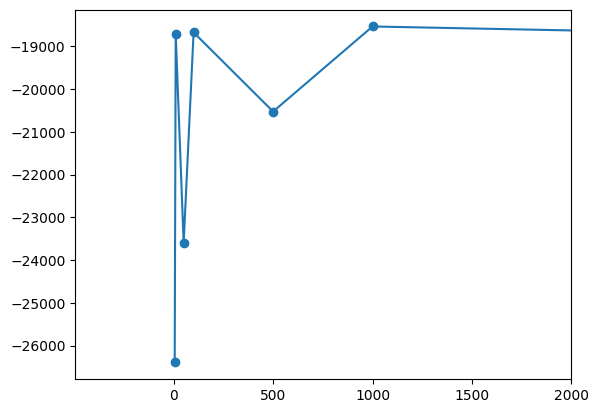

In [32]:
estimators = [5,10,50,100,500,1000,5000,10000]
dec_scores = []
for n_est in estimators:
  scores = IForest(contamination=0.01,n_estimators=n_est).fit(X).decision_scores_
  dec_scores.append(np.sum(scores))

plt.plot(estimators, dec_scores, marker='o', label='Line Data')  # 'marker' adds points to the line for visibility
plt.xlim(right=2000)

In [ ]:
print(f"Aantal gedetecteerde anomalieën: {df_iForest['is_anomaly'].sum()}")

Aantal gedetecteerde anomalieën: 8004


## LOF

In [19]:
from pyod.models.lof import LOF

lof = LOF(contamination=contamination)

In [ ]:
df_lof = predict_model(lof, 'lof')

Training lof!


## COPOD 

In [16]:
from pyod.models.copod import COPOD

copod = COPOD(contamination=contamination)

In [17]:
df_copod = predict_model(copod, 'copod')

Training copod!
Aantal gedetecteerde anomalieën: 1601


In [18]:
print(f"Aantal gedetecteerde anomalieën: {df_copod['is_anomaly'].sum()}")

Aantal gedetecteerde anomalieën: 1601


## ABOD

In [ ]:
from pyod.models.abod import ABOD

abod = ABOD(contamination=contamination, method='fast', n_neighbors=10)

In [ ]:
df_abod = predict_model(abod, 'abod')

C:\Users\Lorem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lorem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\Lorem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,FCATestKey,anomaly_score,is_anomaly
0,1,-3.932284e-07,0
1,2,-7.097304e-07,0
2,3,-4.235548e-07,0
3,4,-2.912532e-07,0
4,5,-8.950200e-07,0


In [ ]:
print(f"Aantal gedetecteerde anomalieën: {df_ecod['is_anomaly'].sum()}")

Aantal gedetecteerde anomalieën: 8004


In [ ]:
df_ecod[df_ecod['is_anomaly'] == 1].head()

,FCATestKey,anomaly_score,is_anomaly
9,10,171.972440,1
13,14,384.554094,1
15,16,162.789406,1
17,18,162.568921,1
18,19,168.080390,1


## Overeenkomsten

### functie voor analyse

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

def compare_anomaly_models(*model_dfs, id_column='TestKey'):
    """
    Vergelijkt anomaliedetecties van meerdere modellen.
    
    :param model_dfs: Een lijst van tuples, elk met (dataframe, model_name)
    :param id_column: De naam van de kolom die als identifier wordt gebruikt
    :return: Een DataFrame met gecombineerde resultaten
    """
    # Initialiseer de gecombineerde DataFrame met de ID-kolom
    df_combined = pd.DataFrame({id_column: model_dfs[0][0][id_column]})
    
    # Voeg resultaten van elk model toe
    model_names = []
    for df, model_name in model_dfs:
        model_names.append(model_name)
        df_combined = df_combined.merge(
            df[[id_column, 'is_anomaly']],
            on=id_column,
            suffixes=('', f'_{model_name}')
        )
        df_combined = df_combined.rename(columns={'is_anomaly': f'{model_name}_anomaly'})
    
    # Tel het aantal anomaliedetecties per datapunt
    anomaly_columns = [col for col in df_combined.columns if col.endswith('_anomaly')]
    df_combined['anomaly_count'] = df_combined[anomaly_columns].sum(axis=1)
    
    # Analyseer de overeenkomsten
    print("Verdeling van anomaliedetecties:")
    print(df_combined['anomaly_count'].value_counts().sort_index())
    
    # # Visualiseer de overeenkomsten
    plt.figure(figsize=(10, 6))
    df_combined['anomaly_count'].value_counts().sort_index().plot(kind='bar')
    plt.title('Aantal datapunten gedetecteerd als anomalie door x modellen')
    plt.xlabel('Aantal modellen')
    plt.ylabel('Aantal datapunten')
    plt.show()
    
    # Bekijk consensus anomalieën
    consensus_anomalies = df_combined[df_combined['anomaly_count'] == len(model_dfs)]
    print(f"\nAantal datapunten gedetecteerd als anomalie door alle {len(model_dfs)} modellen:", 
          len(consensus_anomalies))
    # print("\nVoorbeelden van consensus anomalieën:")
    # print(consensus_anomalies.head())
    
    # Vergelijk modellen paarsgewijs
    print("\nPaarsgewijze vergelijking van modellen:")
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            agreement = (df_combined[f'{model_names[i]}_anomaly'] == df_combined[f'{model_names[j]}_anomaly']).mean()
            print(f"Overeenkomst tussen {model_names[i].upper()} en {model_names[j].upper()}: {agreement:.2%}")
    
    # Visualiseer de overlap van anomalieën met een Venn diagram alleen als er 3 modellen zijn
    if len(model_names) == 3:
        plt.figure(figsize=(8, 7))
        venn3([set(df_combined[df_combined[f'{model}_anomaly'] == 1][id_column]) for model in model_names],
              set_labels=model_names)
        plt.title("Overlap van gedetecteerde anomalieën")
        plt.show()
    else:
        print("\nVenn diagram wordt alleen gemaakt voor exact 3 modellen.")
    
    return df_combined

### uitvoeren

In [ ]:
df_combined = compare_anomaly_models(
    (df_ecod, 'ecod'),
    (df_iForest, 'iforest'),
    (df_lof, 'lof'),
    (df_copod, 'copod'),
    (df_abod, 'abod')
)

Verdeling van anomaliedetecties:
anomaly_count
0    139066
1     10753
2      4371
3      4092
4      1183
5       602
Name: count, dtype: int64

Aantal datapunten gedetecteerd als anomalie door alle 5 modellen: 602

Paarsgewijze vergelijking van modellen:
Overeenkomst tussen ECOD en IFOREST: 96.73%
Overeenkomst tussen ECOD en LOF: 92.18%
Overeenkomst tussen ECOD en COPOD: 99.73%
Overeenkomst tussen ECOD en ABOD: 91.65%
Overeenkomst tussen IFOREST en LOF: 92.39%
Overeenkomst tussen IFOREST en COPOD: 96.73%
Overeenkomst tussen IFOREST en ABOD: 92.09%
Overeenkomst tussen LOF en COPOD: 92.17%
Overeenkomst tussen LOF en ABOD: 93.13%
Overeenkomst tussen COPOD en ABOD: 91.64%

Venn diagram wordt alleen gemaakt voor exact 3 modellen.


In [ ]:
# df_combined.to_csv('../csv/comparison.csv', index=False)

# SOUD

In [ ]:
# from pyod.models.suod import SUOD
# from pyod.models.lof import LOF
# from pyod.models.iforest import IForest
# from pyod.models.copod import COPOD
# from pyod.models.knn import KNN
# from pyod.models.hbos import HBOS

In [ ]:
# base_estimators = [
#     IForest(n_estimators=100, max_samples='auto', contamination=contamination, random_state=42),
#     # LOF(n_neighbors=20, contamination=contamination),
#     ECOD(contamination=contamination),
#     COPOD(contamination=contamination)
# ]

NameError: name 'ECOD' is not defined

In [ ]:
# # Initialiseer SUOD
# suod = SUOD(base_estimators=base_estimators, 
#             n_jobs=2,  # aantal parallelle jobs
#             combination='average',  # methode om scores te combineren
#             verbose=False)

In [ ]:
# def data_generator(X, batch_size=1000):
#     for i in range(0, len(X), batch_size):
#         yield X[i:i + batch_size]

In [ ]:
# # Functie om SUOD te trainen en voorspellingen te maken met batches
# def process_batches(X, batch_size=1000):
#     anomaly_scores = []
    
#     # Train SUOD op batches
#     for batch in data_generator(X, batch_size):
#         suod.fit(batch)  # Train op de huidige batch
#         batch_scores = suod.decision_function(batch)  # Verkrijg anomalie scores voor de batch
#         anomaly_scores.extend(batch_scores)  # Voeg scores toe aan de lijst
    
#     return np.array(anomaly_scores)

In [ ]:
# # Verwerk de data in batches en verkrijg anomalie scores
# print("SUODDDD")
# anomaly_scores = process_batches(X, batch_size=1000)

# # Bepaal anomalieën op basis van de scores (bijvoorbeeld top 5% als anomalieën)
# threshold = np.percentile(anomaly_scores, 95)  # Drempelwaarde instellen
# is_anomaly = anomaly_scores > threshold

RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   16.8s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished


...

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


In [ ]:
# df_suod = pd.DataFrame({
#     'TestKey': np.arange(1, len(X) + 1),  # Voeg een identificatiekolom toe (bijv. FCATestKey)
#     'anomaly_score': anomaly_scores,
#     'is_anomaly': is_anomaly.astype(int)  # Zet booleans om naar integers (0 of 1)
# })

In [ ]:
# print(f"Aantal gedetecteerde anomalieën: {df_suod['is_anomaly'].sum()}")
# print(df_suod.head())  # Toon de eerste paar resultaten

Aantal gedetecteerde anomalieën: 8004
   FCATestKey  anomaly_score  is_anomaly
0           1      -1.030004           0
1           2      -0.503612           0
2           3      -0.899509           0
3           4      -0.369197           0
4           5      -0.186098           0


In [ ]:
# df_suod.to_csv('../csv/suod.csv')